In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

print("NumPy:", np.__version__)
print("PyTorch:", torch.__version__)
print("GPU:", torch.cuda.is_available())

NumPy: 2.4.3
PyTorch: 2.10.0+cpu
GPU: False


In [2]:
import numpy as np

# Vektör — tek bir örneğin özellikleri
x = np.array([1.5, 2.0, 0.5])
print("Vektör:", x)
print("Shape:", x.shape)

# Matris — birden fazla örnek (batch)
X = np.array([
    [1.5, 2.0, 0.5],
    [0.3, 1.1, 2.2],
    [2.1, 0.4, 1.8]
])
print("\nMatris shape:", X.shape)
print("Matris:\n", X)

Vektör: [1.5 2.  0.5]
Shape: (3,)

Matris shape: (3, 3)
Matris:
 [[1.5 2.  0.5]
 [0.3 1.1 2.2]
 [2.1 0.4 1.8]]


In [3]:
# Ağırlıklar ve bias — bunları model eğitimde öğrenecek
w = np.array([0.4, -0.3, 0.7])
b = 0.1

# Tek örnek için nöron çıktısı — bir nöronun yaptığı tam olarak bu
z = np.dot(x, w) + b
print("Tek örnek çıktısı (z):", z)

# Tüm batch için aynı anda
Z = X @ w + b
print("Batch çıktısı:", Z)

Tek örnek çıktısı (z): 0.45000000000000007
Batch çıktısı: [0.45 1.43 2.08]


In [4]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def relu(z):
    return np.maximum(0, z)

def tanh(z):
    return np.tanh(z)

z_test = np.array([-2.0, -0.5, 0.0, 0.5, 2.0])

print("Girdi:  ", z_test)
print("Sigmoid:", sigmoid(z_test).round(3))
print("ReLU:   ", relu(z_test))
print("Tanh:   ", tanh(z_test).round(3))


Girdi:   [-2.  -0.5  0.   0.5  2. ]
Sigmoid: [0.119 0.378 0.5   0.622 0.881]
ReLU:    [0.  0.  0.  0.5 2. ]
Tanh:    [-0.964 -0.462  0.     0.462  0.964]


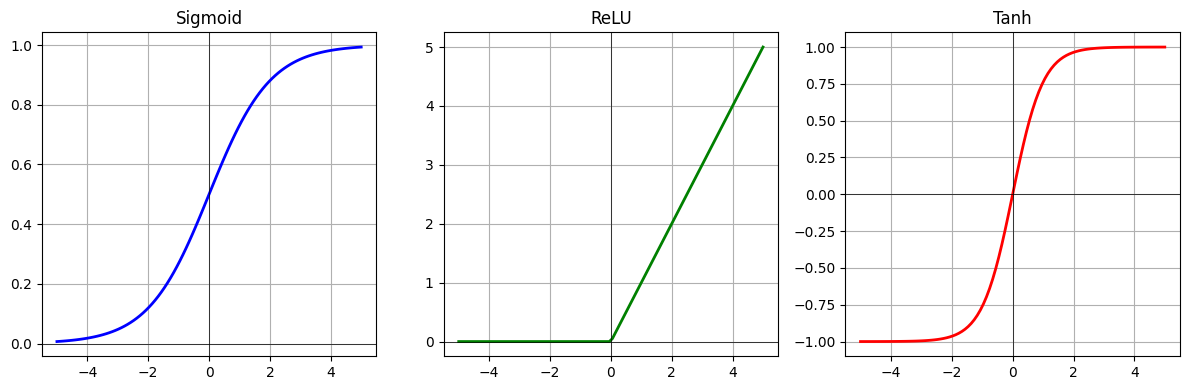

In [5]:
import matplotlib.pyplot as plt

z_range = np.linspace(-5, 5, 100)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(z_range, sigmoid(z_range), color='blue', linewidth=2)
plt.title("Sigmoid")
plt.grid(True)
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)

plt.subplot(1, 3, 2)
plt.plot(z_range, relu(z_range), color='green', linewidth=2)
plt.title("ReLU")
plt.grid(True)
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)

plt.subplot(1, 3, 3)
plt.plot(z_range, tanh(z_range), color='red', linewidth=2)
plt.title("Tanh")
plt.grid(True)
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

In [6]:
# Veri — XOR problemi (klasik test problemi)
# 2 özellik, 4 örnek
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

# Etiketler — XOR çıktısı
y = np.array([[0], [1], [1], [0]])

print("Giriş X:\n", X)
print("Etiketler y:\n", y)

Giriş X:
 [[0 0]
 [0 1]
 [1 0]
 [1 1]]
Etiketler y:
 [[0]
 [1]
 [1]
 [0]]


In [7]:
np.random.seed(42)  # Tekrarlanabilirlik için

# Katman 1: 2 giriş → 3 gizli nöron
W1 = np.random.randn(2, 3) * 0.1
b1 = np.zeros((1, 3))

# Katman 2: 3 gizli nöron → 1 çıkış
W2 = np.random.randn(3, 1) * 0.1
b2 = np.zeros((1, 1))

print("W1 shape:", W1.shape, "\n", W1)
print("\nb1 shape:", b1.shape, "\n", b1)
print("\nW2 shape:", W2.shape, "\n", W2)
print("\nb2 shape:", b2.shape, "\n", b2)

W1 shape: (2, 3) 
 [[ 0.04967142 -0.01382643  0.06476885]
 [ 0.15230299 -0.02341534 -0.0234137 ]]

b1 shape: (1, 3) 
 [[0. 0. 0.]]

W2 shape: (3, 1) 
 [[ 0.15792128]
 [ 0.07674347]
 [-0.04694744]]

b2 shape: (1, 1) 
 [[0.]]


In [8]:
def forward(X, W1, b1, W2, b2):
    # Katman 1
    Z1 = X @ W1 + b1        # (4,2) @ (2,3) = (4,3)
    A1 = relu(Z1)            # Aktivasyon uygula

    # Katman 2
    Z2 = A1 @ W2 + b2       # (4,3) @ (3,1) = (4,1)
    A2 = sigmoid(Z2)         # Çıkış 0-1 arası

    return Z1, A1, Z2, A2

Z1, A1, Z2, A2 = forward(X, W1, b1, W2, b2)

print("Z1 (gizli katman ham):\n", Z1.round(4))
print("\nA1 (gizli katman aktivasyon):\n", A1.round(4))
print("\nZ2 (çıkış ham):\n", Z2.round(4))
print("\nA2 (tahminler):\n", A2.round(4))
print("\nGerçek etiketler:\n", y.T)

Z1 (gizli katman ham):
 [[ 0.      0.      0.    ]
 [ 0.1523 -0.0234 -0.0234]
 [ 0.0497 -0.0138  0.0648]
 [ 0.202  -0.0372  0.0414]]

A1 (gizli katman aktivasyon):
 [[0.     0.     0.    ]
 [0.1523 0.     0.    ]
 [0.0497 0.     0.0648]
 [0.202  0.     0.0414]]

Z2 (çıkış ham):
 [[0.    ]
 [0.0241]
 [0.0048]
 [0.03  ]]

A2 (tahminler):
 [[0.5   ]
 [0.506 ]
 [0.5012]
 [0.5075]]

Gerçek etiketler:
 [[0 1 1 0]]


In [9]:
def binary_cross_entropy(y_true, y_pred):
    # Sayısal kararlılık için küçük epsilon ekle
    eps = 1e-8
    loss = -np.mean(
        y_true * np.log(y_pred + eps) + 
        (1 - y_true) * np.log(1 - y_pred + eps)
    )
    return loss

loss = binary_cross_entropy(y, A2)
print("İlk loss:", round(loss, 4))
print("(Mükemmel model 0'a yakın, rastgele model ~0.69 civarında olur)")

İlk loss: 0.6933
(Mükemmel model 0'a yakın, rastgele model ~0.69 civarında olur)


In [10]:
def backward(X, y, Z1, A1, Z2, A2, W1, W2):
    m = X.shape[0]  # örnek sayısı = 4

    # Katman 2 gradyanları
    dZ2 = A2 - y                        # (4,1)
    dW2 = A1.T @ dZ2 / m               # (3,1)
    db2 = np.mean(dZ2, axis=0)         # (1,1)

    # Katman 1 gradyanları
    dA1 = dZ2 @ W2.T                   # (4,3)
    dZ1 = dA1 * (Z1 > 0)              # ReLU türevi
    dW1 = X.T @ dZ1 / m               # (2,3)
    db1 = np.mean(dZ1, axis=0)        # (1,3)

    return dW1, db1, dW2, db2

dW1, db1, dW2, db2 = backward(X, y, Z1, A1, Z2, A2, W1, W2)

print("dW1 (W1'e göre gradyan):\n", dW1.round(4))
print("\ndW2 (W2'ye göre gradyan):\n", dW2.round(4))

dW1 (W1'e göre gradyan):
 [[ 0.0003  0.     -0.0001]
 [ 0.0005  0.     -0.006 ]]

dW2 (W2'ye göre gradyan):
 [[ 0.0006]
 [ 0.    ]
 [-0.0028]]


In [11]:
def train(X, y, epochs=10000, lr=0.1):
    # Ağırlıkları başlat
    np.random.seed(42)
    W1 = np.random.randn(2, 3) * 0.1
    b1 = np.zeros((1, 3))
    W2 = np.random.randn(3, 1) * 0.1
    b2 = np.zeros((1, 1))

    loss_history = []

    for epoch in range(epochs):
        # İleri besleme
        Z1, A1, Z2, A2 = forward(X, W1, b1, W2, b2)

        # Loss hesapla
        loss = binary_cross_entropy(y, A2)
        loss_history.append(loss)

        # Geri yayılım
        dW1, db1, dW2, db2 = backward(X, y, Z1, A1, Z2, A2, W1, W2)

        # Ağırlıkları güncelle
        W1 -= lr * dW1
        b1 -= lr * db1
        W2 -= lr * dW2
        b2 -= lr * db2

        if epoch % 1000 == 0:
            print(f"Epoch {epoch:5d} | Loss: {loss:.4f}")

    return W1, b1, W2, b2, loss_history

W1, b1, W2, b2, loss_history = train(X, y)

Epoch     0 | Loss: 0.6933
Epoch  1000 | Loss: 0.6932
Epoch  2000 | Loss: 0.6932
Epoch  3000 | Loss: 0.6932
Epoch  4000 | Loss: 0.6932
Epoch  5000 | Loss: 0.6931
Epoch  6000 | Loss: 0.6931
Epoch  7000 | Loss: 0.6931
Epoch  8000 | Loss: 0.6931
Epoch  9000 | Loss: 0.6931


In [12]:
def train_v2(X, y, epochs=10000, lr=1.0):
    np.random.seed(42)
    # Daha büyük başlangıç ağırlıkları
    W1 = np.random.randn(2, 4) * 1.0
    b1 = np.zeros((1, 4))
    W2 = np.random.randn(4, 1) * 1.0
    b2 = np.zeros((1, 1))

    loss_history = []

    for epoch in range(epochs):
        # İleri besleme — tanh kullan, ReLU değil
        Z1 = X @ W1 + b1
        A1 = tanh(Z1)
        Z2 = A1 @ W2 + b2
        A2 = sigmoid(Z2)

        loss = binary_cross_entropy(y, A2)
        loss_history.append(loss)

        # Geri yayılım — tanh türevi: 1 - tanh²
        dZ2 = A2 - y
        dW2 = A1.T @ dZ2 / len(X)
        db2 = np.mean(dZ2, axis=0)

        dA1 = dZ2 @ W2.T
        dZ1 = dA1 * (1 - A1**2)   # tanh türevi
        dW1 = X.T @ dZ1 / len(X)
        db1 = np.mean(dZ1, axis=0)

        W1 -= lr * dW1
        b1 -= lr * db1
        W2 -= lr * dW2
        b2 -= lr * db2

        if epoch % 1000 == 0:
            print(f"Epoch {epoch:5d} | Loss: {loss:.4f}")

    # Son tahminler
    Z1 = X @ W1 + b1
    A1 = tanh(Z1)
    Z2 = A1 @ W2 + b2
    A2 = sigmoid(Z2)
    print("\nSon tahminler:", A2.round(3).T)
    print("Gerçek etiketler:", y.T)

    return W1, b1, W2, b2, loss_history

W1, b1, W2, b2, loss_history = train_v2(X, y)

Epoch     0 | Loss: 0.8451
Epoch  1000 | Loss: 0.0025
Epoch  2000 | Loss: 0.0012
Epoch  3000 | Loss: 0.0008
Epoch  4000 | Loss: 0.0006
Epoch  5000 | Loss: 0.0005
Epoch  6000 | Loss: 0.0004
Epoch  7000 | Loss: 0.0003
Epoch  8000 | Loss: 0.0003
Epoch  9000 | Loss: 0.0003

Son tahminler: [[0. 1. 1. 0.]]
Gerçek etiketler: [[0 1 1 0]]


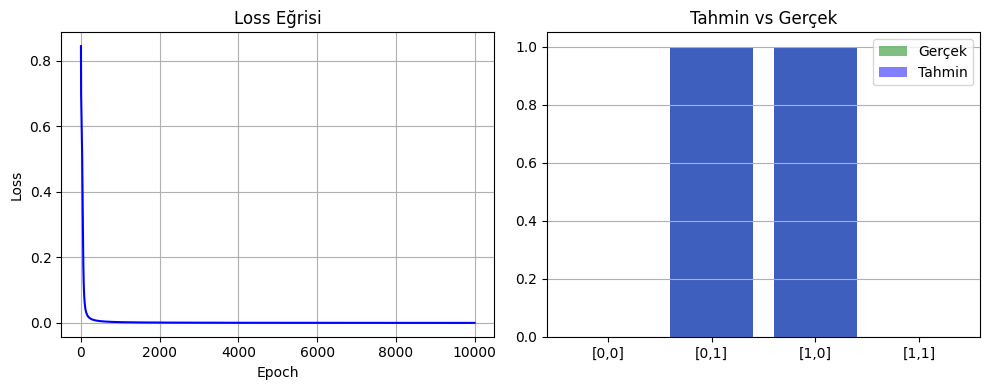

In [13]:
plt.figure(figsize=(10, 4))

# Loss grafiği
plt.subplot(1, 2, 1)
plt.plot(loss_history, color='blue', linewidth=1.5)
plt.title("Loss Eğrisi")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)

# Tahmin vs Gerçek
plt.subplot(1, 2, 2)
Z1 = X @ W1 + b1
A1 = tanh(Z1)
Z2 = A1 @ W2 + b2
A2 = sigmoid(Z2)

x_labels = ['[0,0]', '[0,1]', '[1,0]', '[1,1]']
x_pos = range(4)
plt.bar(x_pos, y.flatten(), alpha=0.5, label='Gerçek', color='green')
plt.bar(x_pos, A2.flatten(), alpha=0.5, label='Tahmin', color='blue')
plt.xticks(x_pos, x_labels)
plt.title("Tahmin vs Gerçek")
plt.legend()
plt.grid(True, axis='y')

plt.tight_layout()
plt.show()

In [14]:
import torch
import torch.nn as nn

# Veriyi PyTorch tensörüne çevir
X_t = torch.FloatTensor(X)
y_t = torch.FloatTensor(y)

# Modeli tanımla
model = nn.Sequential(
    nn.Linear(2, 4),   # Giriş katmanı: 2 → 4
    nn.Tanh(),         # Aktivasyon
    nn.Linear(4, 1),   # Çıkış katmanı: 4 → 1
    nn.Sigmoid()       # Çıkış aktivasyonu
)

# Loss ve optimizer
criterion = nn.BCELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1.0)

print("Model mimarisi:")
print(model)
print("\nToplam parametre sayısı:")
print(sum(p.numel() for p in model.parameters()))

Model mimarisi:
Sequential(
  (0): Linear(in_features=2, out_features=4, bias=True)
  (1): Tanh()
  (2): Linear(in_features=4, out_features=1, bias=True)
  (3): Sigmoid()
)

Toplam parametre sayısı:
17


In [15]:
loss_history_pt = []

for epoch in range(10000):
    # İleri besleme
    y_pred = model(X_t)
    loss = criterion(y_pred, y_t)
    loss_history_pt.append(loss.item())

    # Geri yayılım — 3 satır, hepsi bu!
    optimizer.zero_grad()   # Gradyanları sıfırla
    loss.backward()         # Backprop — otomatik!
    optimizer.step()        # Ağırlıkları güncelle

    if epoch % 1000 == 0:
        print(f"Epoch {epoch:5d} | Loss: {loss.item():.4f}")

# Son tahminler
with torch.no_grad():
    predictions = model(X_t)
    print("\nSon tahminler:", predictions.round().T)
    print("Gerçek etiketler:", y_t.T)

Epoch     0 | Loss: 0.7078
Epoch  1000 | Loss: 0.0029
Epoch  2000 | Loss: 0.0013
Epoch  3000 | Loss: 0.0008
Epoch  4000 | Loss: 0.0006
Epoch  5000 | Loss: 0.0005
Epoch  6000 | Loss: 0.0004
Epoch  7000 | Loss: 0.0003
Epoch  8000 | Loss: 0.0003
Epoch  9000 | Loss: 0.0002

Son tahminler: tensor([[0., 1., 1., 0.]])
Gerçek etiketler: tensor([[0., 1., 1., 0.]])


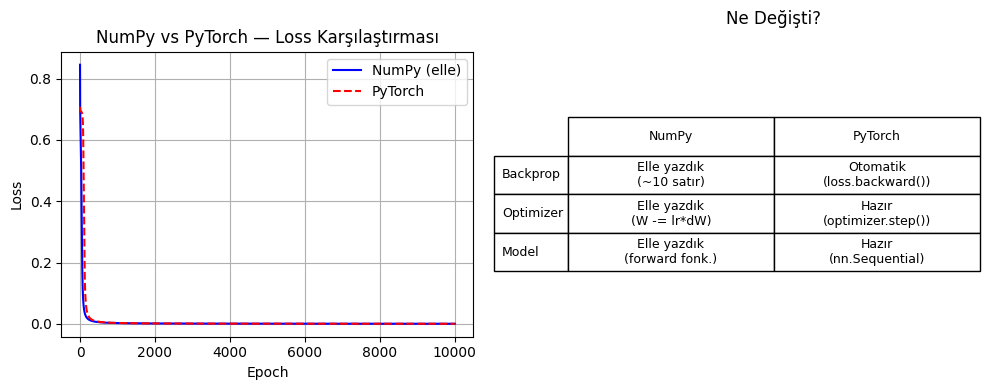

In [16]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(loss_history, label='NumPy (elle)', color='blue', linewidth=1.5)
plt.plot(loss_history_pt, label='PyTorch', color='red', linewidth=1.5, linestyle='--')
plt.title("NumPy vs PyTorch — Loss Karşılaştırması")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
farklar = [
    ("Backprop", "Elle yazdık\n(~10 satır)", "Otomatik\n(loss.backward())"),
    ("Optimizer", "Elle yazdık\n(W -= lr*dW)", "Hazır\n(optimizer.step())"),
    ("Model", "Elle yazdık\n(forward fonk.)", "Hazır\n(nn.Sequential)"),
]

plt.axis('off')
tablo = plt.table(
    cellText=[[f[1], f[2]] for f in farklar],
    rowLabels=[f[0] for f in farklar],
    colLabels=["NumPy", "PyTorch"],
    cellLoc='center',
    loc='center'
)
tablo.scale(1, 2.5)
tablo.auto_set_font_size(False)
tablo.set_fontsize(9)
plt.title("Ne Değişti?", pad=20)

plt.tight_layout()
plt.show()